# Storm Trajectory + Intensity Prediction — Training (Warmup Windows)

Full training pipeline with **left-zero-padding + attention masking**, which allows the model
to make predictions from the very first storm timestep (not just after 8 observations).

Key differences vs the original `model_transformer.ipynb`:
- `_make_windows()` now generates **warmup windows** for the first 7 timesteps of every storm
- Each window carries a `mask` tensor (`True` = padded, `False` = real observation)
- `StormTransformer.forward()` accepts an optional `mask` and passes it to `TransformerEncoder` as `src_key_padding_mask`
- `scaler_X` is fit on **real rows only** (not zero-padded positions) to avoid bias
- Padded positions are **re-zeroed** after scaling
- Training/validation loops unpack 4-item batches `(X, y, ctx, mask)`

Sections:
1. Environment setup
2. Build datasets
3. Model architecture
4. GPU check
5. Training
6. Evaluation
7. Comparison vs Random Forest baseline
8. Trajectory plots
9. Loss curves
10. Epoch log

## 1 · Environment Setup

In [1]:
import os
import sys
import json
from pathlib import Path
from dotenv import load_dotenv

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")

assert "DATABASE_URL" in os.environ, (
    "DATABASE_URL not found — add it to .env at the project root."
)

print("DATABASE_URL loaded successfully.")

DATABASE_URL loaded successfully.


## 2 · Build Datasets

In [2]:
import numpy as np
import torch
from src.model.dataset import build_datasets, SEQ_LEN, N_FEATURES, N_ROLLOUT_STEPS

# save_scalers=False here — train() in Section 5 will save the definitive scalers
train_ds, val_ds, test_ds, scaler_X, scaler_y = build_datasets(save_scalers=False)

# Shape checks — dataset now returns 4 items (X, y, ctx, mask)
X_sample, y_sample, ctx_sample, mask_sample = train_ds[0]

assert X_sample.shape    == (SEQ_LEN, N_FEATURES),   f"X shape wrong: {X_sample.shape}"
assert y_sample.shape    == (N_ROLLOUT_STEPS, 3),    f"y shape wrong: {y_sample.shape}"
assert ctx_sample.shape  == (2,),                    f"ctx shape wrong: {ctx_sample.shape}"
assert mask_sample.shape == (SEQ_LEN,),              f"mask shape wrong: {mask_sample.shape}"
assert mask_sample.dtype == torch.bool,              f"mask dtype wrong: {mask_sample.dtype}"

print(f"Train windows : {len(train_ds):,}")
print(f"Val windows   : {len(val_ds):,}")
print(f"Test windows  : {len(test_ds):,}")
print()
print(f"X shape    : {tuple(X_sample.shape)}   — [SEQ_LEN={SEQ_LEN}, N_FEATURES={N_FEATURES}]")
print(f"y shape    : {tuple(y_sample.shape)}  — [N_ROLLOUT_STEPS={N_ROLLOUT_STEPS}, N_TARGETS=3]")
print(f"ctx shape  : {tuple(ctx_sample.shape)}        — (basin_id, season_norm)")
print(f"mask shape : {tuple(mask_sample.shape)}        — bool, True=padded position")
print()
print("First warmup window mask (predicting from obs_0 only):")
print(f"  {mask_sample.tolist()}")
print(f"  → {mask_sample.sum().item()} padded, {(~mask_sample).sum().item()} real")

Loading data from database...


C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)


  Loaded 132,646 rows, 2,343 unique storms.
  Train storms: 2,019 | Val: 158 | Test: 166
  Windows - Train: 99,208 | Val: 7,561 | Test: 7,209
  Train basin distribution: {'EP': 2260, 'NI': 44, 'WP': 96904}
  Val basin distribution: {'EP': 88, 'WP': 7473}
  Test basin distribution: {'EP': 130, 'WP': 7079}
Train windows : 99,208
Val windows   : 7,561
Test windows  : 7,209

X shape    : (8, 16)   — [SEQ_LEN=8, N_FEATURES=16]
y shape    : (8, 3)  — [N_ROLLOUT_STEPS=8, N_TARGETS=3]
ctx shape  : (2,)        — (basin_id, season_norm)
mask shape : (8,)        — bool, True=padded position

First warmup window mask (predicting from obs_0 only):
  [True, True, True, True, True, True, True, False]
  → 7 padded, 1 real


In [3]:
# Scaler sanity: real (non-padded) rows should be ~N(0,1)
real_X = train_ds.X[~train_ds.mask].numpy()   # [M, N_FEATURES]
mean_abs = abs(real_X.mean())
print(f"Scaler sanity (real rows only)")
print(f"  Global mean    : {real_X.mean():.4f}  (expect ≈ 0)")
print(f"  Avg feature std: {real_X.std(axis=0).mean():.4f}  (expect ≈ 1)")
assert mean_abs < 0.5, f"Scaling looks off — mean_abs={mean_abs:.4f}"

# Padded rows must be exactly 0
pad_X = train_ds.X[train_ds.mask].numpy()
assert pad_X.max() == 0.0 and pad_X.min() == 0.0, "Padded rows are not zero!"
print(f"  Padded rows    : {len(pad_X):,} timesteps — all zeros")

Scaler sanity (real rows only)
  Global mean    : -0.0000  (expect ≈ 0)
  Avg feature std: 0.9373  (expect ≈ 1)
  Padded rows    : 54,981 timesteps — all zeros


## 3 · Model Architecture

In [4]:
import importlib
import src.model.transformer
importlib.reload(src.model.transformer)

from src.model.transformer import StormTransformer, count_parameters
from src.model.dataset import N_BASINS, N_ROLLOUT_STEPS

model = StormTransformer(n_features=N_FEATURES, n_basins=N_BASINS)
print(model)
print(f"\nTotal trainable parameters: {count_parameters(model):,}")

# Forward-pass sanity: full window
dummy_x    = torch.randn(32, SEQ_LEN, N_FEATURES)
dummy_ctx  = torch.zeros(32, 2)
dummy_mask = torch.zeros(32, SEQ_LEN, dtype=torch.bool)  # no padding
out = model(dummy_x, dummy_ctx, mask=dummy_mask)
assert out.shape == (32, N_ROLLOUT_STEPS, 3), f"Expected (32, {N_ROLLOUT_STEPS}, 3), got {out.shape}"
print(f"\nFull window  : input {tuple(dummy_x.shape)} → output {tuple(out.shape)}  ✓")

# Warmup window: 7 padded + 1 real (first storm timestep)
warmup_mask = torch.ones(32, SEQ_LEN, dtype=torch.bool)
warmup_mask[:, -1] = False
out_w = model(dummy_x, dummy_ctx, mask=warmup_mask)
assert out_w.shape == (32, N_ROLLOUT_STEPS, 3)
print(f"Warmup window: 7 padded + 1 real → output {tuple(out_w.shape)}  ✓")

StormTransformer(
  (input_proj): Linear(in_features=16, out_features=64, bias=True)
  (pos_emb): Embedding(8, 64)
  (basin_emb): Embedding(7, 64)
  (season_proj): Linear(in_features=1, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (

## 4 · GPU Check

In [5]:
cuda_available = torch.cuda.is_available()
print(f"CUDA available : {cuda_available}")

if cuda_available:
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU            : {gpu_name}")
    print(f"VRAM           : {vram_gb:.1f} GB")
    x = torch.randn(4, SEQ_LEN, N_FEATURES).cuda()
    print(f"Tensor device  : {x.device}")
    del x
    torch.cuda.empty_cache()
    print("\nTraining will use GPU.")
else:
    print("\nNo CUDA GPU detected — training will use CPU.")

CUDA available : True
GPU            : NVIDIA GeForce RTX 5060
VRAM           : 8.0 GB
Tensor device  : cuda:0

Training will use GPU.


## 5 · Training

In [7]:
import importlib
import src.model.transformer, src.model.train
importlib.reload(src.model.transformer)
importlib.reload(src.model.train)

from src.model.train import train

model, training_log = train()
print(f"\nTraining complete. Epochs run: {len(training_log)}")

Device: cuda - NVIDIA GeForce RTX 5060 (8.0 GB VRAM)
Loading data from database...


C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)


  Loaded 132,646 rows, 2,343 unique storms.
  Train storms: 2,019 | Val: 158 | Test: 166
  Windows - Train: 99,208 | Val: 7,561 | Test: 7,209
  Train basin distribution: {'EP': 2260, 'NI': 44, 'WP': 96904}
  Val basin distribution: {'EP': 88, 'WP': 7473}
  Test basin distribution: {'EP': 130, 'WP': 7079}
  Scalers saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/
Parameters: 157,848
AMP enabled    : False
Epoch 001/100 | Train loss: 26.15 km | Val loss: 12.32 km | Val Haversine: 10.2 km | LR: 1.000e-03 | Time: 7.8s
  --> Saved checkpoint (val loss 12.32 km)
Epoch 002/100 | Train loss: 12.70 km | Val loss: 10.49 km | Val Haversine: 10.0 km | LR: 9.998e-04 | Time: 6.7s
  --> Saved checkpoint (val loss 10.49 km)
Epoch 003/100 | Train loss: 10.99 km | Val loss: 8.86 km | Val Haversine: 8.5 km | LR: 9.990e-04 | Time: 6.6s
  --> Saved checkpoint (val loss 8.86 km)
Epoch 004/100 | Train loss: 10.38 km | Val loss: 9.23 km | Val Haversine: 8.7 km | LR: 9.978e-04 | Time: 6.6s
Epoc

## 6 · Evaluation

In [8]:
import importlib, joblib
import src.model.transformer, src.model.evaluate
importlib.reload(src.model.transformer)
importlib.reload(src.model.evaluate)

from src.model.evaluate import load_model, evaluate_test

MODELS_DIR = PROJECT_ROOT / "models"
scaler_X = joblib.load(MODELS_DIR / "scaler_X.pkl")
scaler_y = joblib.load(MODELS_DIR / "scaler_y.pkl")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_eval = load_model(device)

hav_km, wind_mae = evaluate_test(model_eval, test_ds, scaler_X, scaler_y, device)


=== Test Set Metrics ===
  Mean Haversine distance : 8.4 km
  Median Haversine        : 7.0 km
  Wind speed MAE          : 3.11 knots


In [9]:
# Percentile breakdown
print("Haversine distance percentiles (km)")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:>2} : {np.percentile(hav_km, p):.1f} km")
print(f"  max : {hav_km.max():.1f} km")

Haversine distance percentiles (km)
  p10 : 2.7 km
  p25 : 4.5 km
  p50 : 7.0 km
  p75 : 10.3 km
  p90 : 14.5 km
  p95 : 18.7 km
  p99 : 36.6 km
  max : 96.5 km


## 6b · Forecast Horizon Errors (24 h / 48 h)

Standard metric in tropical cyclone track forecasting literature.

- **24 h error** = direct 8-step prediction (one forward pass, sum 8 predicted deltas)
- **48 h error** = chunk chaining: 2 forward passes of 8 steps, chained at the boundary

No autoregressive rollout — the model outputs all 8 future steps simultaneously from real observations only.

In [10]:
from src.model.dataset import (
    _load_from_db, _engineer_features, FEATURE_COLS, N_FEATURES,
    SEQ_LEN, N_ROLLOUT_STEPS, haversine_km,
)

STEP_HOURS = 3                          # each model step = 3 h
HORIZONS   = {24: 24 // STEP_HOURS,    # 8 steps
              48: 48 // STEP_HOURS}     # 16 steps


def compute_multi_horizon_errors(model, scaler_X, scaler_y, device, horizons):
    """
    Direct multi-horizon prediction: one forward pass per 8-step chunk.
    24h = 1 forward pass (sum 8 predicted deltas).
    48h = 2 forward passes chained at the 8-step boundary.
    """
    max_steps = max(horizons.values())   # e.g. 16 for 48h

    df = _load_from_db()
    df = _engineer_features(df)
    test_storms = df[df["season"] >= 2020]["atcf_id"].unique()

    step_errors = {n: [] for n in horizons.values()}

    def build_window(feats_norm, end_idx):
        """Build [1, SEQ_LEN, N_FEATURES] window ending at end_idx (inclusive)."""
        real_start = max(0, end_idx + 1 - SEQ_LEN)
        window = feats_norm[real_start : end_idx + 1]
        real_len = len(window)
        pad_len = SEQ_LEN - real_len
        if pad_len > 0:
            window = np.concatenate([np.zeros((pad_len, N_FEATURES), np.float32), window])
        mask = np.array([True] * pad_len + [False] * real_len)
        win_t  = torch.tensor(window, dtype=torch.float32, device=device).unsqueeze(0)
        mask_t = torch.tensor(mask, device=device).unsqueeze(0)
        return win_t, mask_t

    def make_predicted_rows(feats_norm, pred_raw, start_lat, start_lon):
        """Build N_ROLLOUT_STEPS normalized feature rows from predicted deltas."""
        rows = []
        cur_lat, cur_lon = start_lat, start_lon
        last_raw = scaler_X.inverse_transform(feats_norm[-1:])
        for j in range(len(pred_raw)):
            d_lat, d_lon, wind = pred_raw[j, 0], pred_raw[j, 1], pred_raw[j, 2]
            cur_lat += d_lat
            cur_lon += d_lon
            new_raw = last_raw.copy()
            new_raw[0, 0] = cur_lat
            new_raw[0, 1] = cur_lon
            new_raw[0, 2] = d_lat
            new_raw[0, 3] = d_lon
            new_raw[0, 7] = wind
            rows.append(scaler_X.transform(new_raw)[0])
            last_raw = new_raw
        return np.array(rows, dtype=np.float32)  # [8, 16]

    model.eval()
    with torch.no_grad():
        for sid in test_storms:
            storm = df[df["atcf_id"] == sid].reset_index(drop=True)
            if len(storm) < max_steps + 1:
                continue
            feats_raw  = storm[FEATURE_COLS].values.astype(np.float32)
            feats_norm = scaler_X.transform(feats_raw).astype(np.float32)
            basin_id    = int(storm["basin_id"].iloc[0])
            season_norm = float(storm["season_norm"].iloc[0])
            ctx = torch.tensor([[basin_id, season_norm]], dtype=torch.float32, device=device)

            for start in range(len(storm) - max_steps):
                start_lat = float(feats_raw[start, 0])
                start_lon = float(feats_raw[start, 1])

                # --- Chunk 1: steps 1-8 (24h) ---
                win_t, mask_t = build_window(feats_norm, start)
                pred_norm_out = model(win_t, ctx, mask=mask_t)           # [1, 8, 3]
                pred_raw1 = scaler_y.inverse_transform(pred_norm_out[0].cpu().numpy())  # [8, 3]
                cum_lat1 = start_lat + pred_raw1[:, 0].cumsum()
                cum_lon1 = start_lon + pred_raw1[:, 1].cumsum()

                if 8 in step_errors:
                    true_lat = float(feats_raw[start + 8, 0])
                    true_lon = float(feats_raw[start + 8, 1])
                    err = haversine_km(np.array([true_lat]), np.array([true_lon]),
                                      np.array([cum_lat1[-1]]), np.array([cum_lon1[-1]]))[0]
                    step_errors[8].append(err)

                # --- Chunk 2: steps 9-16 (48h) ---
                if 16 in step_errors:
                    pred_rows = make_predicted_rows(
                        feats_norm[max(0, start + 1 - SEQ_LEN) : start + 1],
                        pred_raw1, start_lat, start_lon,
                    )
                    context = np.concatenate([feats_norm[max(0, start + 1):start + 1], pred_rows])
                    context = context[-SEQ_LEN:]
                    pad_len = SEQ_LEN - len(context)
                    if pad_len > 0:
                        context = np.concatenate([np.zeros((pad_len, N_FEATURES), np.float32), context])
                    mask2 = np.array([True] * pad_len + [False] * (SEQ_LEN - pad_len))
                    win2_t  = torch.tensor(context, dtype=torch.float32, device=device).unsqueeze(0)
                    mask2_t = torch.tensor(mask2, device=device).unsqueeze(0)
                    pred_norm2 = model(win2_t, ctx, mask=mask2_t)
                    pred_raw2 = scaler_y.inverse_transform(pred_norm2[0].cpu().numpy())
                    lat_48h = cum_lat1[-1] + pred_raw2[:, 0].cumsum()[-1]
                    lon_48h = cum_lon1[-1] + pred_raw2[:, 1].cumsum()[-1]
                    true_lat = float(feats_raw[start + 16, 0])
                    true_lon = float(feats_raw[start + 16, 1])
                    err = haversine_km(np.array([true_lat]), np.array([true_lon]),
                                      np.array([lat_48h]),   np.array([lon_48h]))[0]
                    step_errors[16].append(err)

    return {hours: np.array(step_errors[n]) for hours, n in horizons.items()}


print("Computing 24 h / 48 h forecast errors (direct multi-horizon)…")
horizon_errors = compute_multi_horizon_errors(model_eval, scaler_X, scaler_y, device, HORIZONS)

for h, errs in horizon_errors.items():
    print(f"\n  {h}h forecast error  (n={len(errs):,} samples)")
    print(f"    Mean   : {errs.mean():.1f} km")
    print(f"    Median : {np.median(errs):.1f} km")

Computing 24 h / 48 h forecast errors (direct multi-horizon)…


C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)
c:\Users\Admin\anaconda3\envs\storm_trajectory\lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(



  24h forecast error  (n=5,935 samples)
    Mean   : 146.5 km
    Median : 126.7 km

  48h forecast error  (n=5,935 samples)
    Mean   : 405.3 km
    Median : 357.7 km


In [11]:
import pandas as pd
# Horizon error summary table
rows = [{"Horizon": "3h  (direct, step-1)",
         "N samples": len(hav_km),
         "Mean (km)": round(float(hav_km.mean()), 1),
         "Median (km)": round(float(np.median(hav_km)), 1)}]

for h in sorted(horizon_errors):
    errs = horizon_errors[h]
    rows.append({"Horizon": f"{h}h (direct multi-horizon)",
                 "N samples": len(errs),
                 "Mean (km)": round(float(errs.mean()), 1),
                 "Median (km)": round(float(np.median(errs)), 1)})

display(pd.DataFrame(rows))

,Horizon,N samples,Mean (km),Median (km)
0,"3h (direct, step-1)",7209,8.4,7.0
1,24h (direct multi-horizon),5935,146.5,126.7
2,48h (direct multi-horizon),5935,405.3,357.7


## 8 · Trajectory Plots

C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)


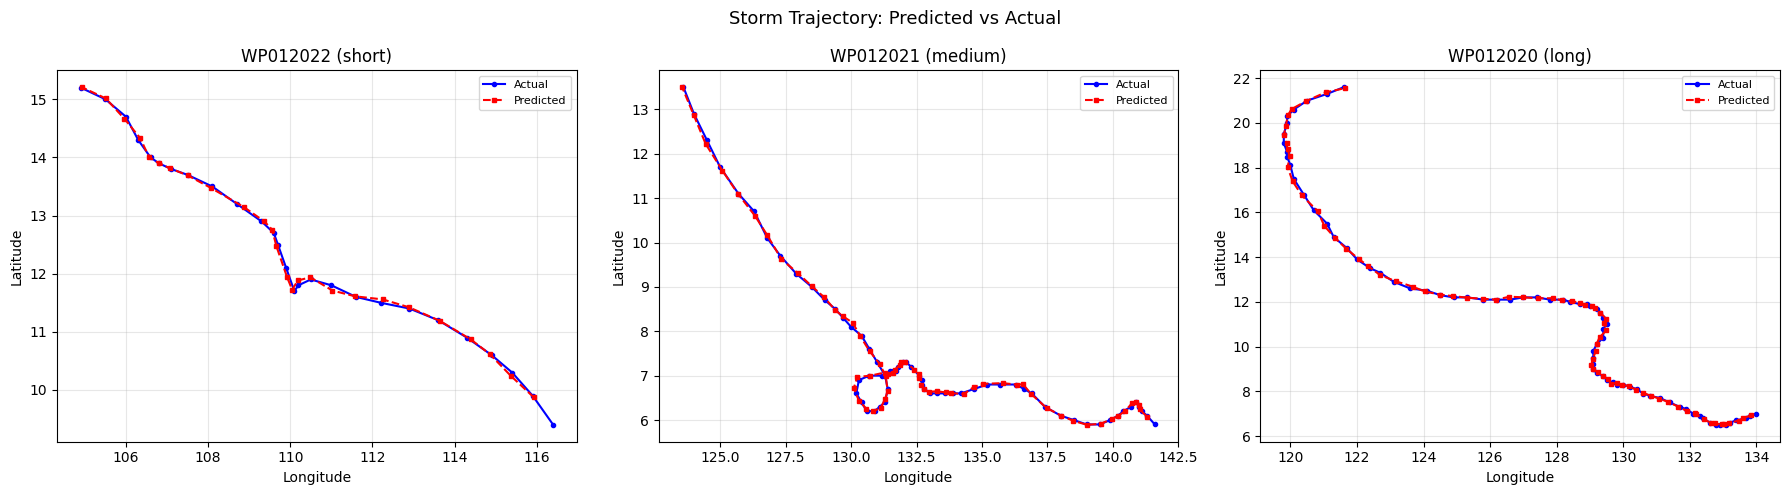

Trajectory plot saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/trajectory_plots.png


In [12]:
from src.model.evaluate import plot_trajectories

plot_trajectories(scaler_X, scaler_y, device)

### 8b · Earth Background Trajectory Plots

Same three storms rendered on a real Earth map using cartopy PlateCarree
projection with NASA Blue Marble background, coastlines, and borders.

Requires: `pip install cartopy>=0.22.0`

C:\Users\Admin\Desktop\Predict_storm_trajectory\src\model\dataset.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(SQL, conn)
c:\Users\Admin\anaconda3\envs\storm_trajectory\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\Admin\anaconda3\envs\storm_trajectory\lib\site-packages\cartopy\io\__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


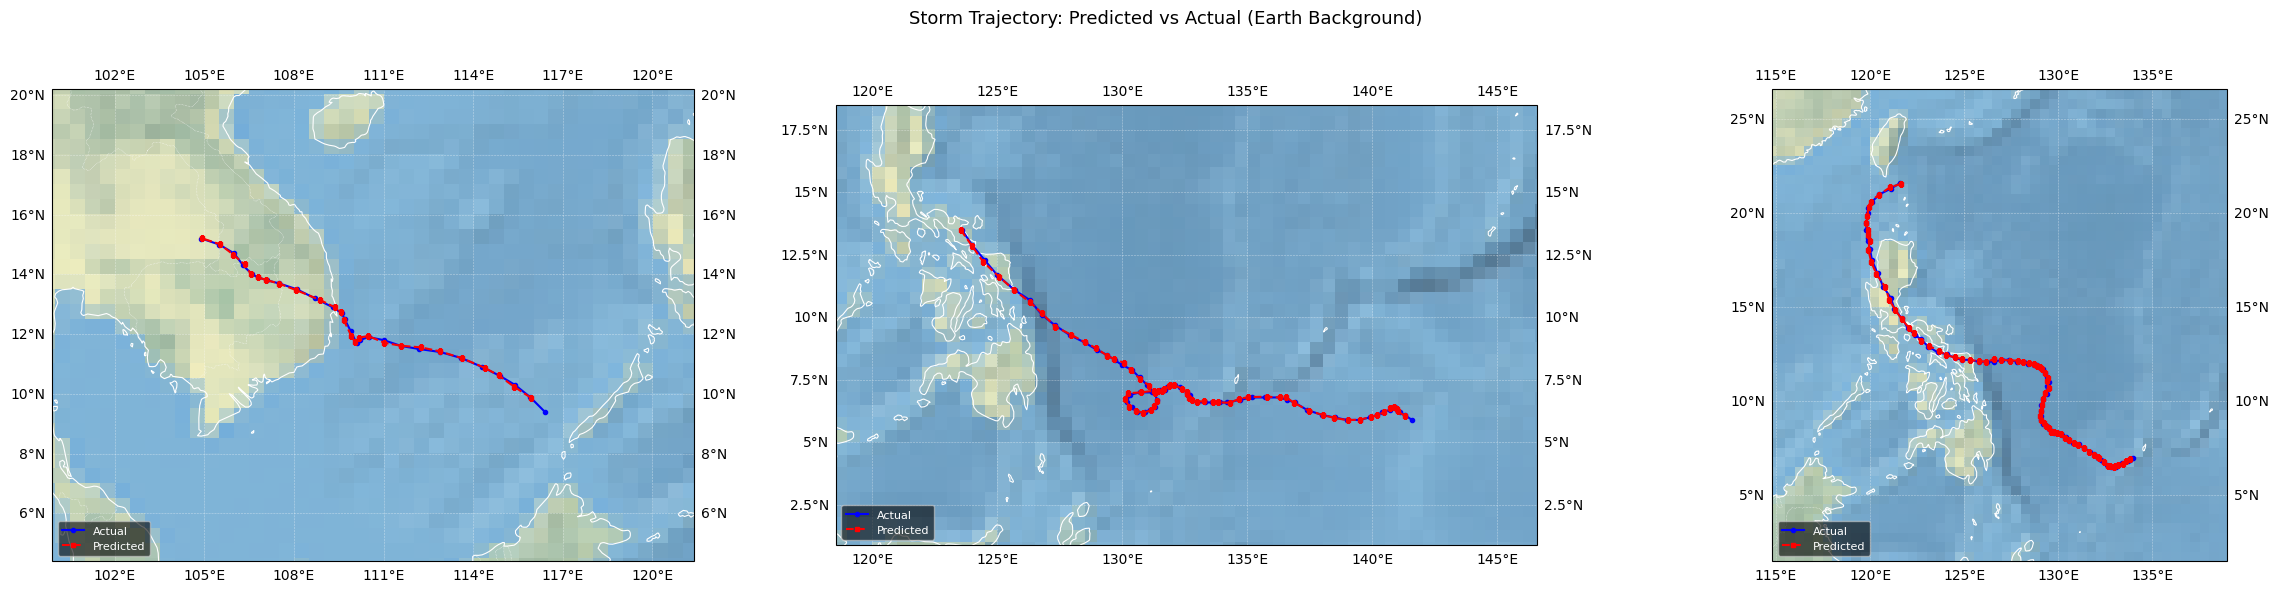

Earth trajectory plot saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models\trajectory_plots_earth.png


In [15]:
import importlib
import src.model.evaluate
importlib.reload(src.model.evaluate)

from src.model.evaluate import plot_trajectories_earth

plot_trajectories_earth(scaler_X, scaler_y, device)

## 9 · Loss Curves

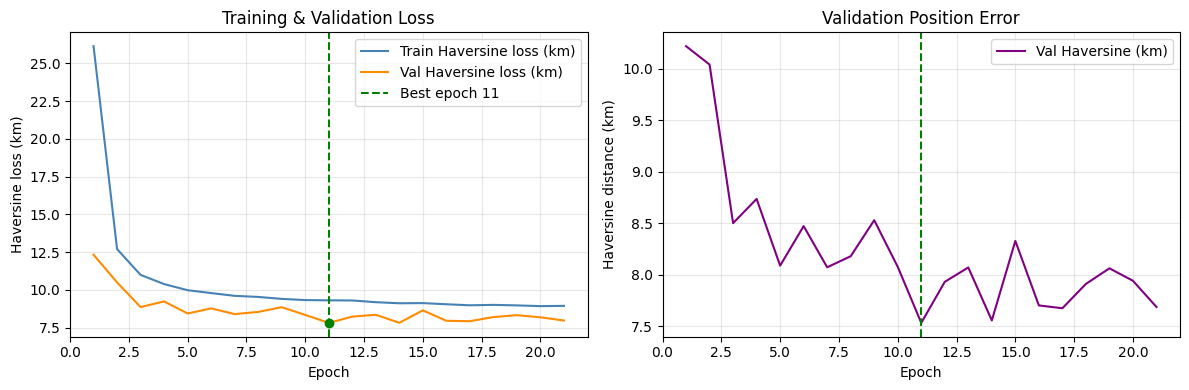

Loss curve saved to C:\Users\Admin\Desktop\Predict_storm_trajectory\models/loss_curves.png


In [13]:
from src.model.evaluate import plot_loss_curves

plot_loss_curves()

## 10 · Detailed Epoch Log

In [14]:
log_df = pd.DataFrame(training_log)
display(log_df)

best_row = log_df.loc[log_df["val_loss_km"].idxmin()]
print(f"\nBest epoch      : {int(best_row['epoch'])}")
print(f"  Val loss (km) : {best_row['val_loss_km']:.2f}")
print(f"  Val Haversine : {best_row['val_haversine_km']:.1f} km")

,epoch,train_loss_km,val_loss_km,val_haversine_km,lr
0,1,26.145206,12.324881,10.216910,0.001000
1,2,12.696155,10.492480,10.038493,0.001000
2,3,10.988413,8.857350,8.500323,0.000999
3,4,10.379162,9.231070,8.735579,0.000998
4,5,9.973483,8.431598,8.088442,0.000996
5,6,9.784280,8.767805,8.471848,0.000994
6,7,9.600215,8.391408,8.072342,0.000991
7,8,9.528892,8.534410,8.179795,0.000988
8,9,9.399532,8.848313,8.528968,0.000984
9,10,9.319932,8.335027,8.076969,0.000980



Best epoch      : 11
  Val loss (km) : 7.81
  Val Haversine : 7.5 km
